## Step 1: Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.shape

(200, 5)

In [7]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [9]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [11]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

## Step 3: Data Preparation
We select **Annual Income** and **Spending Score** as the main features for clustering.

In [13]:
# Select features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

In [15]:
 X.shape

(200, 2)

---
# Part A: K-Means Clustering

## Step 4: Find Optimal K — Elbow Method

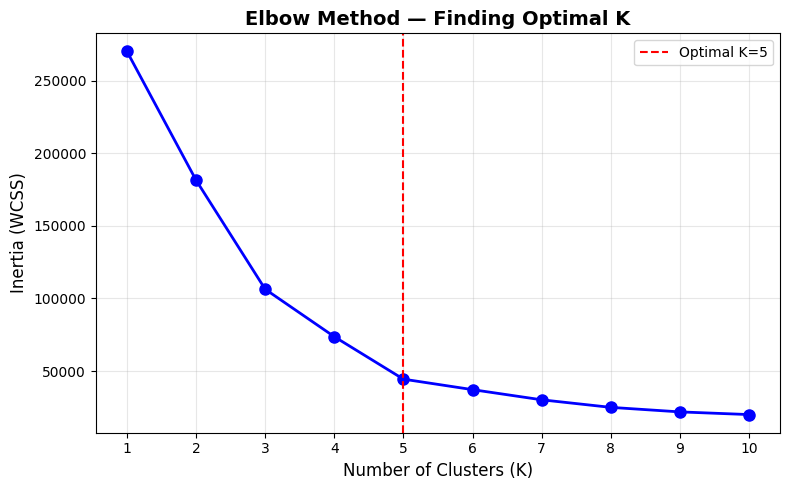

In [16]:
# Elbow Method
inertia_values = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X)
    inertia_values.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, 'bo-', markersize=8, linewidth=2)
plt.axvline(x=5, color='red', linestyle='--', label='Optimal K=5')
plt.title('Elbow Method — Finding Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (WCSS)', fontsize=12)
plt.xticks(k_range)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 5: Find Optimal K — Silhouette Method

In [6]:
# Silhouette Method
silhouette_scores = []
k_range_sil = range(2, 11)  # silhouette requires at least 2 clusters

for k in k_range_sil:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)
    print(f'K={k}: Silhouette Score = {score:.4f}')

optimal_k_sil = k_range_sil[np.argmax(silhouette_scores)]
print(f'\nBest Silhouette Score at K = {optimal_k_sil}')

K=2: Silhouette Score = 0.2969
K=3: Silhouette Score = 0.4676
K=4: Silhouette Score = 0.4932
K=5: Silhouette Score = 0.5539
K=6: Silhouette Score = 0.5398
K=7: Silhouette Score = 0.5288
K=8: Silhouette Score = 0.4548
K=9: Silhouette Score = 0.4561
K=10: Silhouette Score = 0.4411

Best Silhouette Score at K = 5


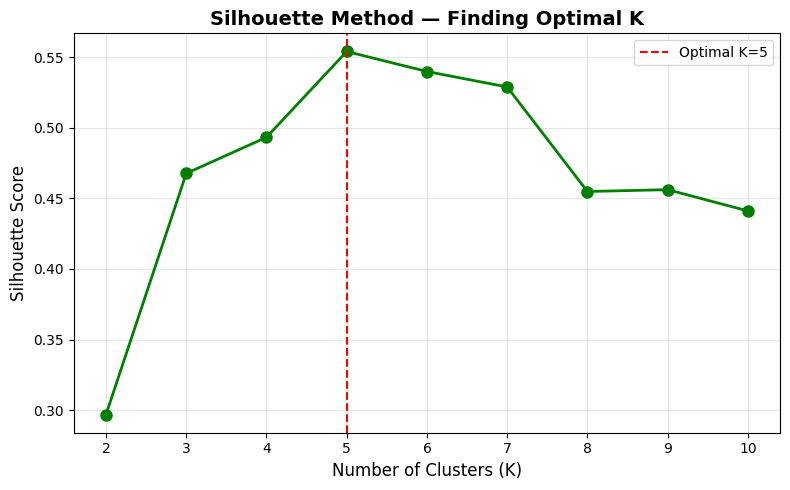


Conclusion: Both Elbow and Silhouette methods agree on K = 5


In [7]:
plt.figure(figsize=(8, 5))
plt.plot(list(k_range_sil), silhouette_scores, 'go-', markersize=8, linewidth=2)
plt.axvline(x=optimal_k_sil, color='red', linestyle='--', label=f'Optimal K={optimal_k_sil}')
plt.title('Silhouette Method — Finding Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(list(k_range_sil))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nConclusion: Both Elbow and Silhouette methods agree on K = 5')

## Step 6: Apply K-Means with K=5

In [8]:
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X)

print('K-Means Cluster Labels:')
print(df['KMeans_Cluster'].value_counts().sort_index())
print('\nCluster Centers (Annual Income, Spending Score):')
print(kmeans.cluster_centers_)

K-Means Cluster Labels:
KMeans_Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Cluster Centers (Annual Income, Spending Score):
[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


## Step 7: K-Means Visualization — Plot 1: Spending Score vs Age

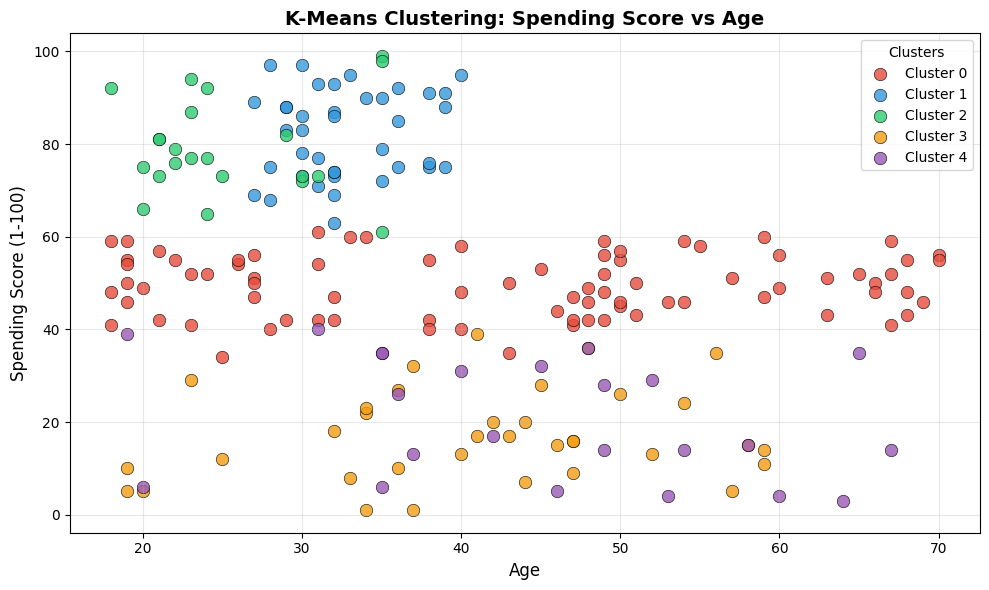

In [9]:
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']

plt.figure(figsize=(10, 6))
for i in range(optimal_k):
    subset = df[df['KMeans_Cluster'] == i]
    plt.scatter(subset['Age'], subset['Spending Score (1-100)'],
                c=colors[i], label=cluster_names[i], s=80, alpha=0.8, edgecolors='black', linewidth=0.5)

plt.title('K-Means Clustering: Spending Score vs Age', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(title='Clusters', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 8: K-Means Visualization — Plot 2: Spending Score vs Annual Income

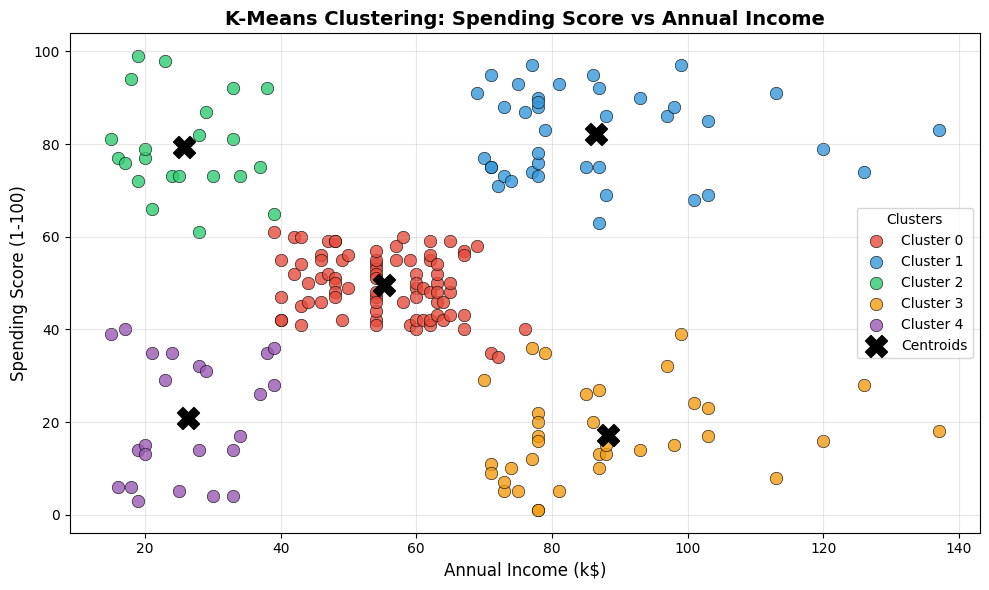

In [10]:
plt.figure(figsize=(10, 6))
for i in range(optimal_k):
    subset = df[df['KMeans_Cluster'] == i]
    plt.scatter(subset['Annual Income (k$)'], subset['Spending Score (1-100)'],
                c=colors[i], label=cluster_names[i], s=80, alpha=0.8, edgecolors='black', linewidth=0.5)

# Plot cluster centers
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=250, c='black', marker='X', zorder=5, label='Centroids')

plt.title('K-Means Clustering: Spending Score vs Annual Income', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(title='Clusters', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# Part B: Agglomerative (Hierarchical) Clustering

## Step 9: Dendrogram to Determine Number of Clusters

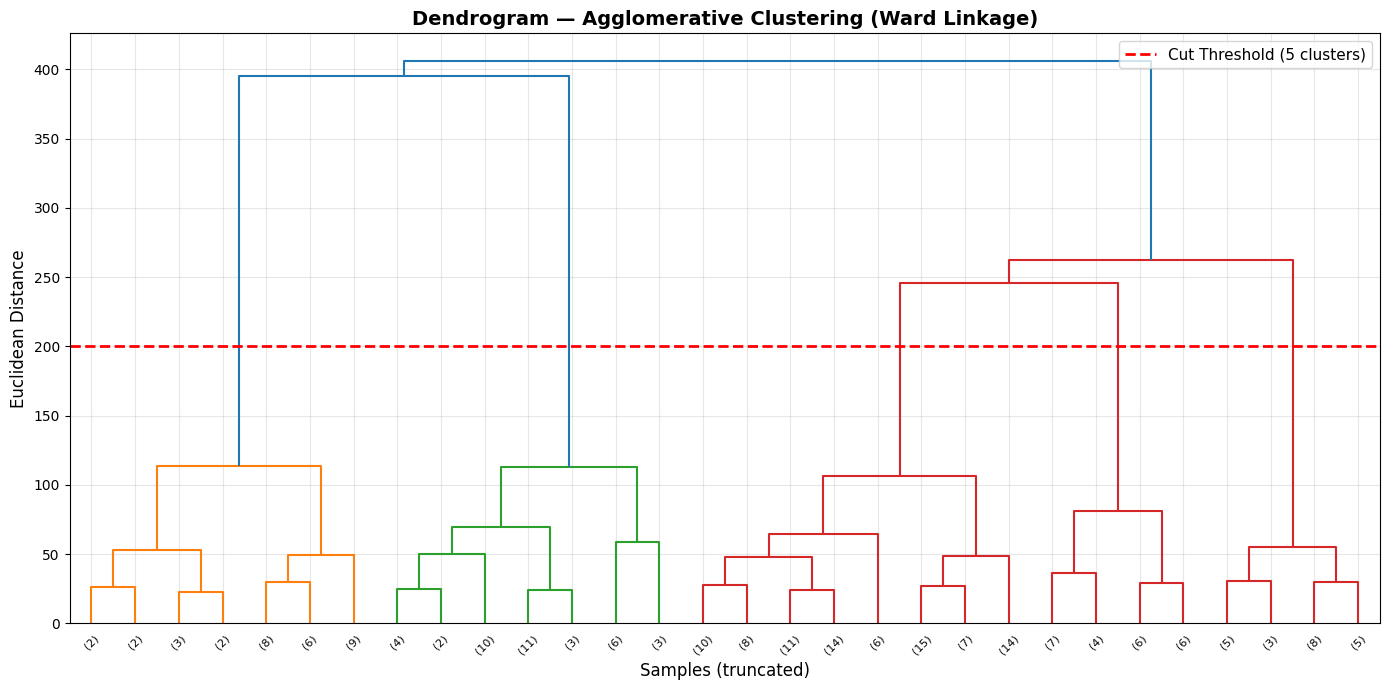

Dendrogram Analysis:
- The red dashed line cuts the dendrogram at ~200 distance
- This creates 5 vertical lines (branches) = 5 clusters
- We choose K=5 to be consistent with K-Means for comparison


In [11]:
# Compute linkage matrix
linked = linkage(X, method='ward')

plt.figure(figsize=(14, 7))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True,
           truncate_mode='lastp',
           p=30,
           leaf_font_size=8)

# Draw a horizontal line at the cut threshold
plt.axhline(y=200, color='red', linestyle='--', linewidth=2, label='Cut Threshold (5 clusters)')
plt.title('Dendrogram — Agglomerative Clustering (Ward Linkage)', fontsize=14, fontweight='bold')
plt.xlabel('Samples (truncated)', fontsize=12)
plt.ylabel('Euclidean Distance', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Dendrogram Analysis:')
print('- The red dashed line cuts the dendrogram at ~200 distance')
print('- This creates 5 vertical lines (branches) = 5 clusters')
print('- We choose K=5 to be consistent with K-Means for comparison')

## Step 10: Apply Agglomerative Clustering with K=5

In [12]:
agg = AgglomerativeClustering(n_clusters=5, linkage='ward')
df['Agg_Cluster'] = agg.fit_predict(X)

print('Agglomerative Cluster Labels:')
print(df['Agg_Cluster'].value_counts().sort_index())

Agglomerative Cluster Labels:
Agg_Cluster
0    32
1    85
2    39
3    21
4    23
Name: count, dtype: int64


## Step 11: Agglomerative Visualization — Plot 3: Spending Score vs Age

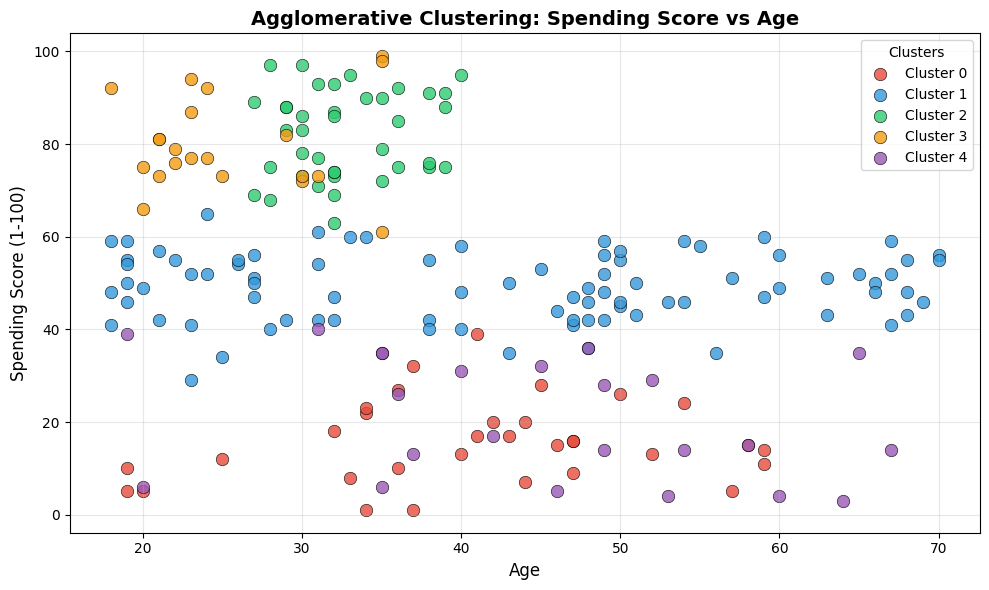

In [13]:
plt.figure(figsize=(10, 6))
for i in range(5):
    subset = df[df['Agg_Cluster'] == i]
    plt.scatter(subset['Age'], subset['Spending Score (1-100)'],
                c=colors[i], label=f'Cluster {i}', s=80, alpha=0.8, edgecolors='black', linewidth=0.5)

plt.title('Agglomerative Clustering: Spending Score vs Age', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(title='Clusters', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 12: Agglomerative Visualization — Plot 4: Spending Score vs Annual Income

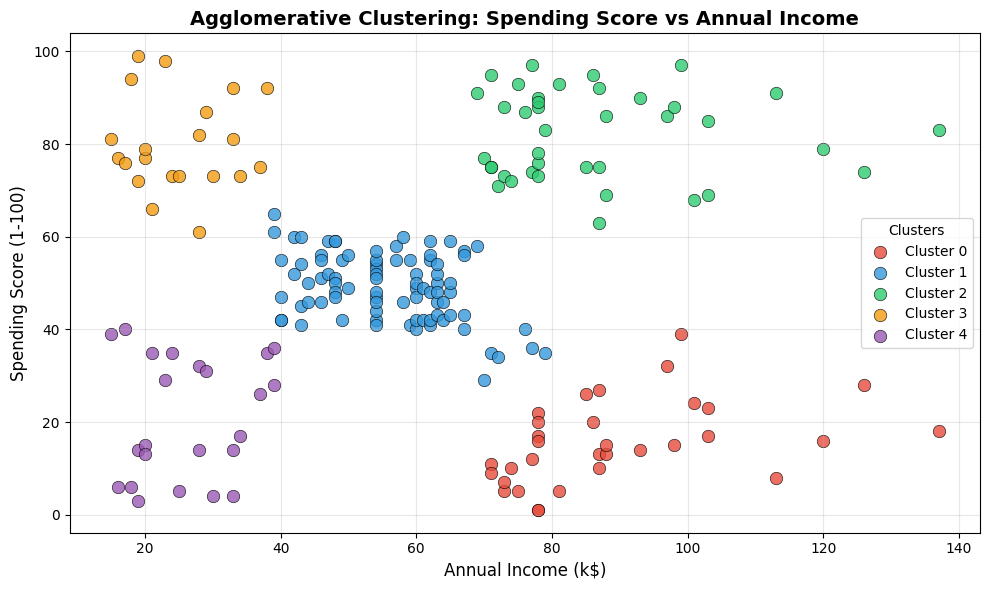

In [14]:
plt.figure(figsize=(10, 6))
for i in range(5):
    subset = df[df['Agg_Cluster'] == i]
    plt.scatter(subset['Annual Income (k$)'], subset['Spending Score (1-100)'],
                c=colors[i], label=f'Cluster {i}', s=80, alpha=0.8, edgecolors='black', linewidth=0.5)

plt.title('Agglomerative Clustering: Spending Score vs Annual Income', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(title='Clusters', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# Part C: Analysis & Comparison

## Step 13: Print All Cluster Labels

## Step 14: Compare Silhouette Scores of Both Algorithms

In [16]:
kmeans_sil = silhouette_score(X, df['KMeans_Cluster'])
agg_sil    = silhouette_score(X, df['Agg_Cluster'])

print('='*50)
print(f'  K-Means Silhouette Score     : {kmeans_sil:.4f}')
print(f'  Agglomerative Silhouette Score: {agg_sil:.4f}')
print('='*50)

if kmeans_sil > agg_sil:
    print('\nWinner: K-Means produces better-defined clusters for this dataset.')
else:
    print('\nWinner: Agglomerative Clustering produces better-defined clusters for this dataset.')

  K-Means Silhouette Score     : 0.5539
  Agglomerative Silhouette Score: 0.5530

Winner: K-Means produces better-defined clusters for this dataset.
